# Quality Control and Preprocessing of GEO scRNA-seq Data

# 01 - Load and Inspect Dataset

This notebook loads the GEO dataset **GSE272840** and inspects the AnnData structure before downstream analysis.

In [1]:
# Import libraries
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs("../figures", exist_ok=True)
os.makedirs("../results", exist_ok=True)

# Set plotting defaults
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=120, facecolor="white")

# Load dataset
adata = sc.read_h5ad("../data/GSE272840_ALO_viscRNAseq.h5ad")

# Inspect AnnData object
adata

/var/folders/_1/p4599gn10_n6drwzgptc86g80000gn/T/ipykernel_1583/3951270338.py:14: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=120, facecolor="white")


AnnData object with n_obs × n_vars = 21044 × 39895
    obs: 'species', 'run', 'ID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'high_quality', 'viral_counts', 'cell_type'
    var: 'gene_id', 'gene_name', 'genome'

In [2]:
# Inspect cell metadata
adata.obs.head()

,species,run,ID,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,high_quality,viral_counts,cell_type
01_01_06-run1,GRCh38,run1,24h_uninfected_DMSO,4722,12330.0,1422.0,11.532846,True,0.0,Basal-like cells
01_01_62-run1,GRCh38,run1,24h_uninfected_DMSO,2791,6445.0,703.0,10.907681,True,0.0,Basal-like cells
01_01_86-run1,GRCh38,run1,24h_uninfected_DMSO,3044,7478.0,248.0,3.316395,True,0.0,Basal-like cells
01_02_36-run1,GRCh38,run1,24h_uninfected_DMSO,6292,28805.0,1320.0,4.582538,True,0.0,AT1-like cells
01_03_05-run1,GRCh38,run1,24h_uninfected_DMSO,3499,10248.0,929.0,9.065184,True,0.0,Basal-like cells


In [3]:
# Inspect metadata columns
adata.obs.columns

Index(['species', 'run', 'ID', 'n_genes_by_counts', 'total_counts',
       'total_counts_mt', 'pct_counts_mt', 'high_quality', 'viral_counts',
       'cell_type'],
      dtype='object')

In [4]:
# Inspect gene metadata
adata.var.head()

,gene_id,gene_name,genome
gene,,,
TSPAN6,ENSG00000000003,TSPAN6,GRCh38
TNMD,ENSG00000000005,TNMD,GRCh38
DPM1,ENSG00000000419,DPM1,GRCh38
SCYL3,ENSG00000000457,SCYL3,GRCh38
C1orf112,ENSG00000000460,C1orf112,GRCh38


# 02 - Inspect Experimental Conditions

This step inspects the number of cells per experimental condition.

In [5]:
# Count cells per condition
adata.obs["ID"].value_counts()

ID
24h_infected_DMSO         8761
24h_infected_RMC-113      7980
24h_uninfected_RMC-113    1875
24h_uninfected_DMSO       1429
4h_uninfected_RMC-113      342
4h_uninfected_DMSO         270
4h_infected_RMC-113        250
4h_infected_DMSO           137
Name: count, dtype: int64

# 03 - Cell Distribution Across Experimental Conditions

This plot shows the number of cells captured for each condition.
The dataset contains eight conditions combining timepoint, infection status, and treatment.

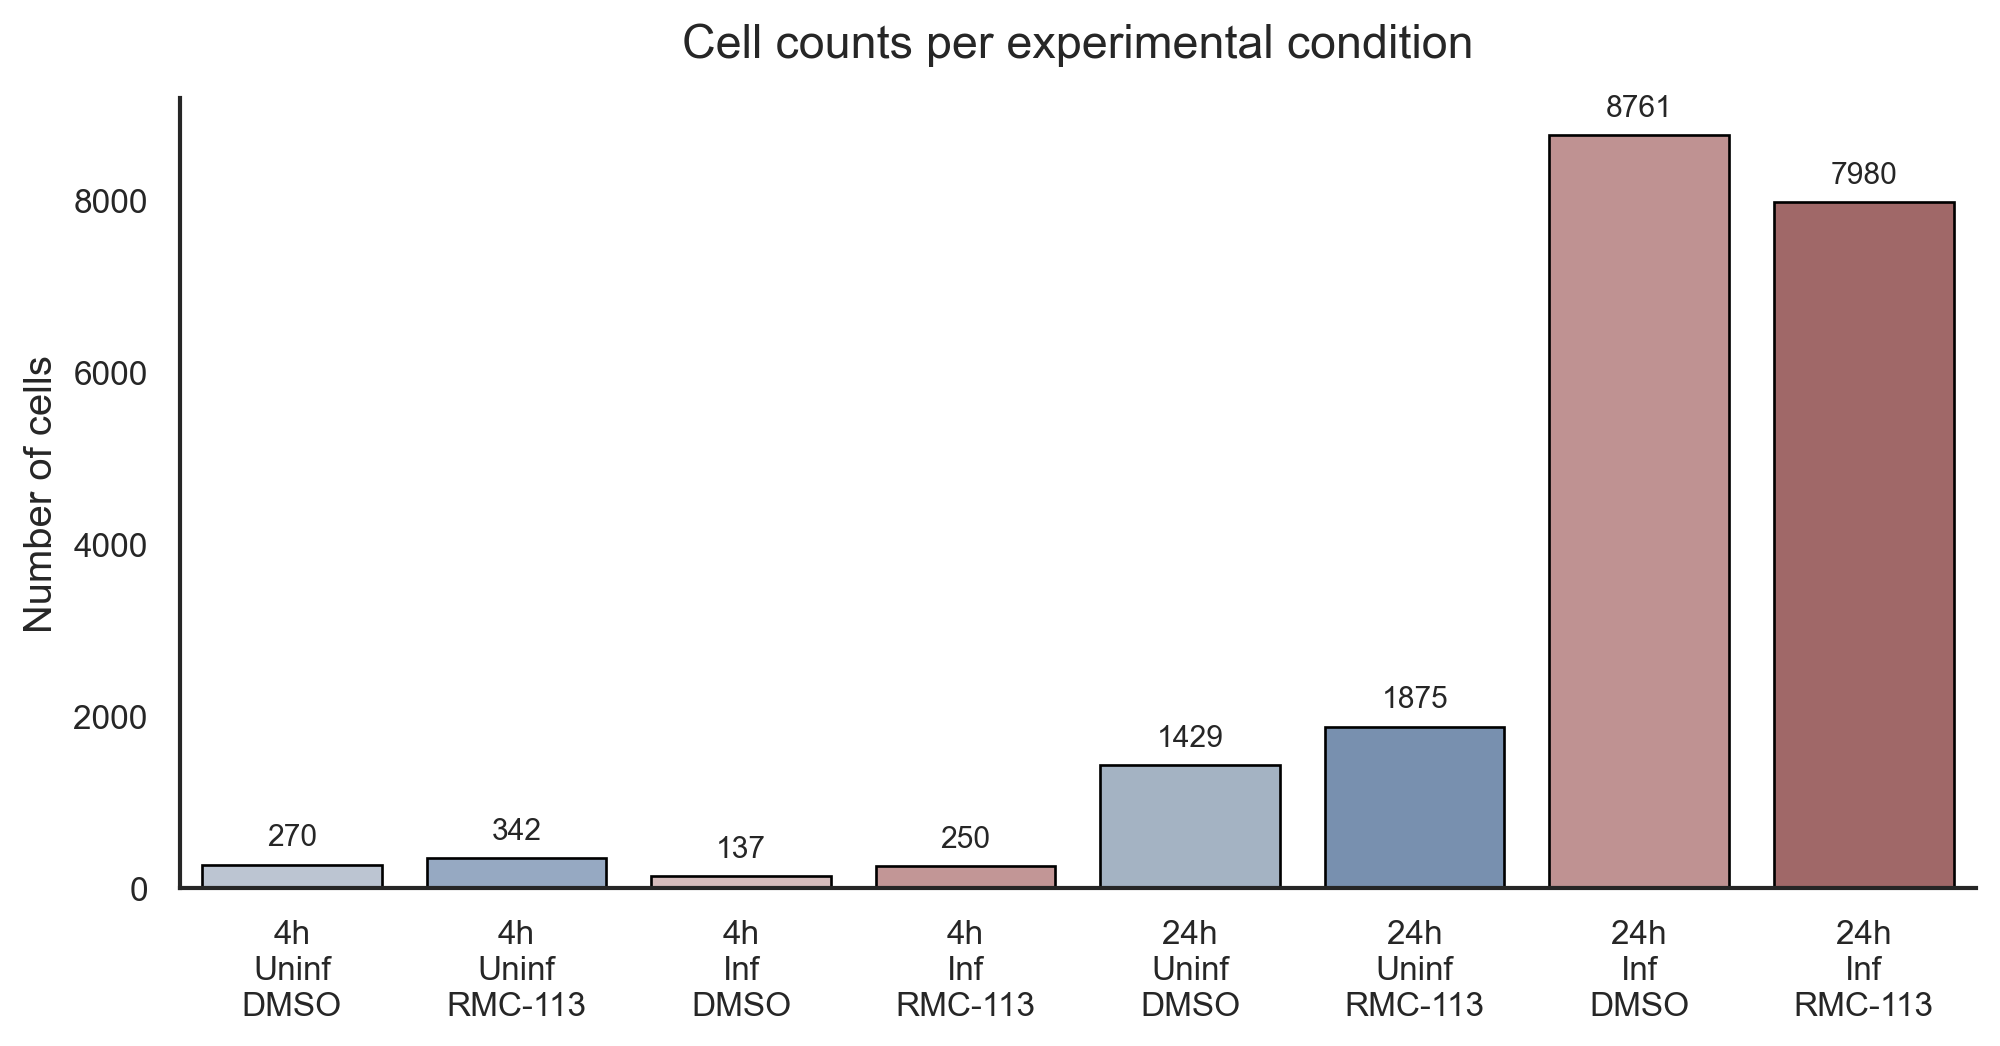

In [6]:
# Count cells per condition
condition_counts = adata.obs["ID"].value_counts()

# Create plotting table
df_counts = condition_counts.reset_index()
df_counts.columns = ["condition", "n_cells"]

# Set condition order
order = [
    "4h_uninfected_DMSO",
    "4h_uninfected_RMC-113",
    "4h_infected_DMSO",
    "4h_infected_RMC-113",
    "24h_uninfected_DMSO",
    "24h_uninfected_RMC-113",
    "24h_infected_DMSO",
    "24h_infected_RMC-113"
]

df_counts["condition"] = pd.Categorical(
    df_counts["condition"],
    categories=order,
    ordered=True
)
df_counts = df_counts.sort_values("condition")

# Create short labels
label_map = {
    "4h_uninfected_DMSO": "4h\nUninf\nDMSO",
    "4h_uninfected_RMC-113": "4h\nUninf\nRMC-113",
    "4h_infected_DMSO": "4h\nInf\nDMSO",
    "4h_infected_RMC-113": "4h\nInf\nRMC-113",
    "24h_uninfected_DMSO": "24h\nUninf\nDMSO",
    "24h_uninfected_RMC-113": "24h\nUninf\nRMC-113",
    "24h_infected_DMSO": "24h\nInf\nDMSO",
    "24h_infected_RMC-113": "24h\nInf\nRMC-113"
}
df_counts["label"] = df_counts["condition"].map(label_map)

# Define colors
palette = [
    "#B8C4D6", "#8FA8C9", "#D9B8B8", "#C98F8F",
    "#9FB3C8", "#6F8FB8", "#C68A8A", "#A95F5F"
]

# Set theme
sns.set_theme(style="white")

# Create figure
fig, ax = plt.subplots(figsize=(8.5, 4.5))

# Plot bars
sns.barplot(
    data=df_counts,
    x="label",
    y="n_cells",
    hue="condition",
    palette=palette,
    dodge=False,
    edgecolor="black",
    linewidth=0.8,
    legend=False,
    ax=ax
)

# Add bar labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=9, padding=4)

# Style figure
ax.set_title("Cell counts per experimental condition", fontsize=14, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Number of cells", fontsize=12)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

# Save figure
plt.tight_layout()
plt.savefig("../figures/Figure_01_cell_counts_per_condition.png", dpi=300, bbox_inches="tight")
plt.show()

# 04 - Quality Control Assessment

Inspect standard single-cell QC metrics:
- number of detected genes per cell
- total counts per cell
- mitochondrial percentage

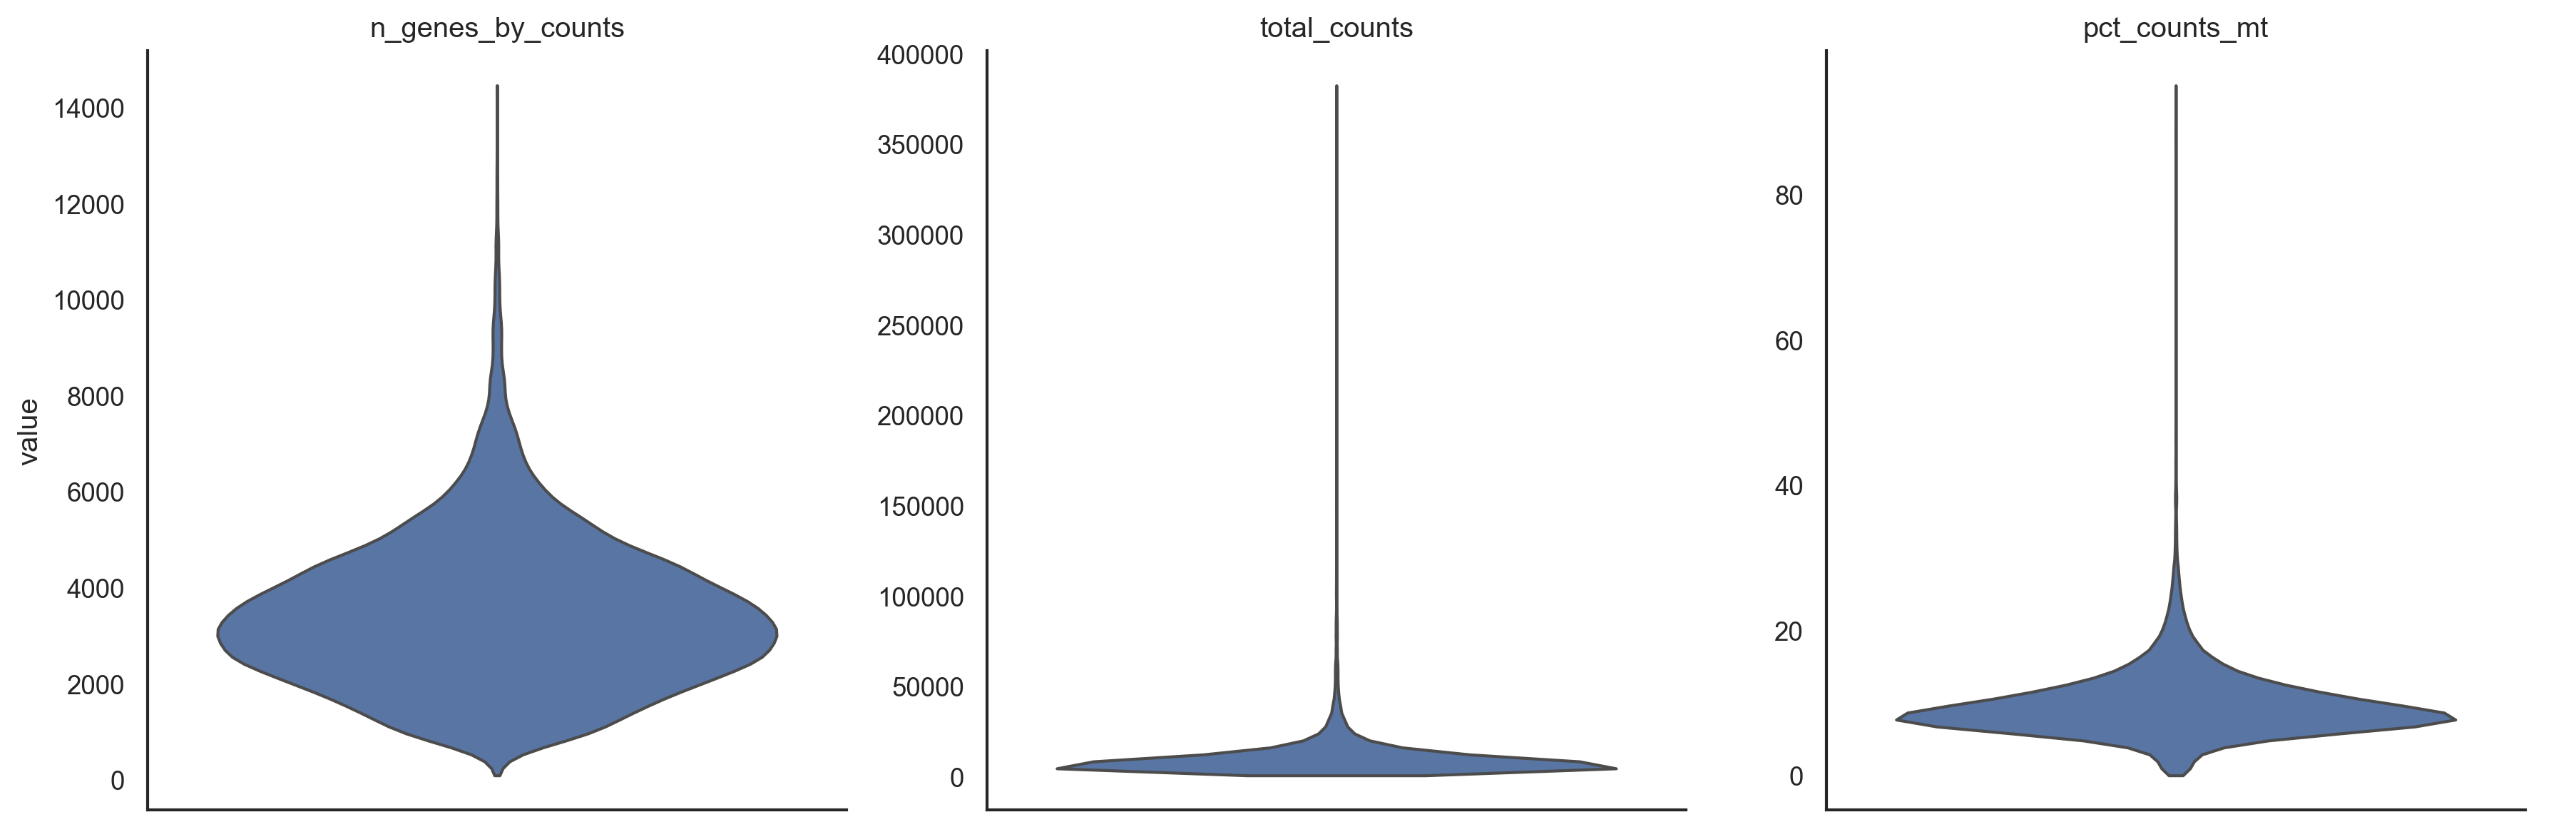

In [7]:
# Define QC metrics
qc_metrics = ["n_genes_by_counts", "total_counts", "pct_counts_mt"]

# Plot violin plots
sc.pl.violin(
    adata,
    qc_metrics,
    jitter=0.2,
    stripplot=False,
    multi_panel=True,
    show=False
)

plt.savefig("../figures/Figure_02_qc_violin.png", dpi=300, bbox_inches="tight")
plt.show()

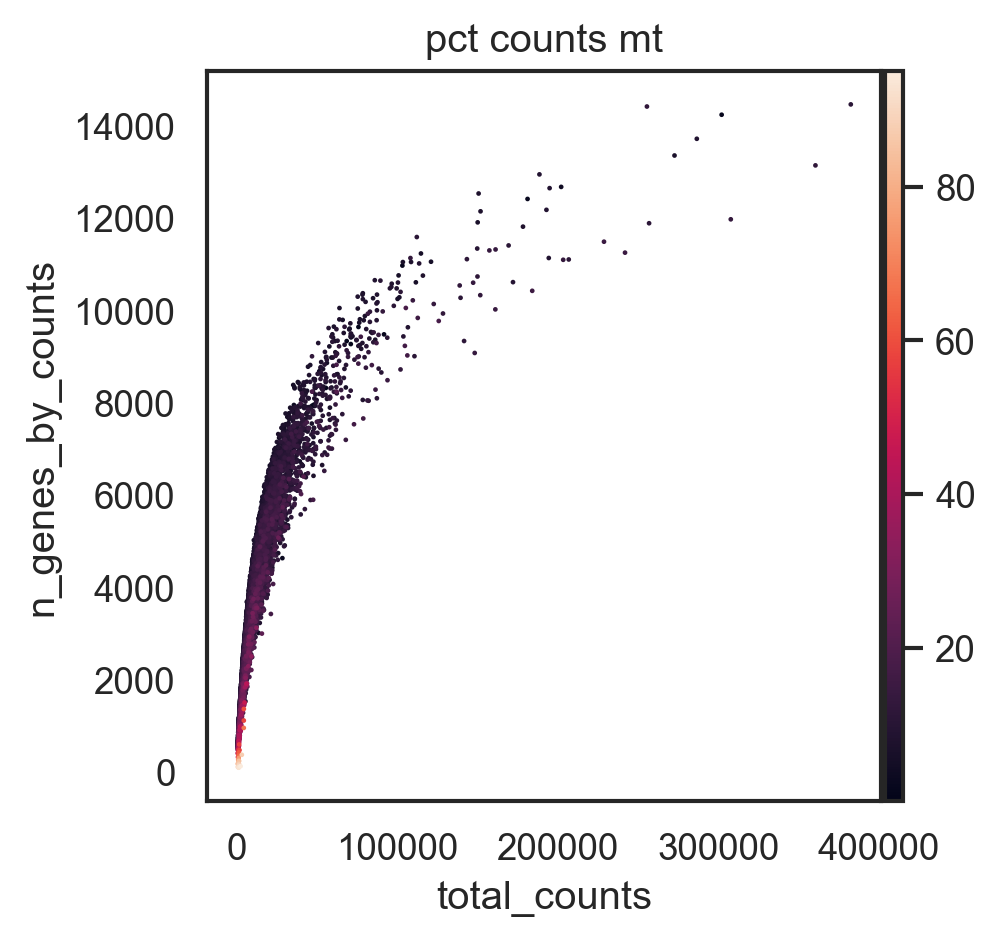

In [8]:
# Plot genes vs counts
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
    size=8,
    frameon=False,
    show=False
)

plt.savefig("../figures/Figure_03_qc_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

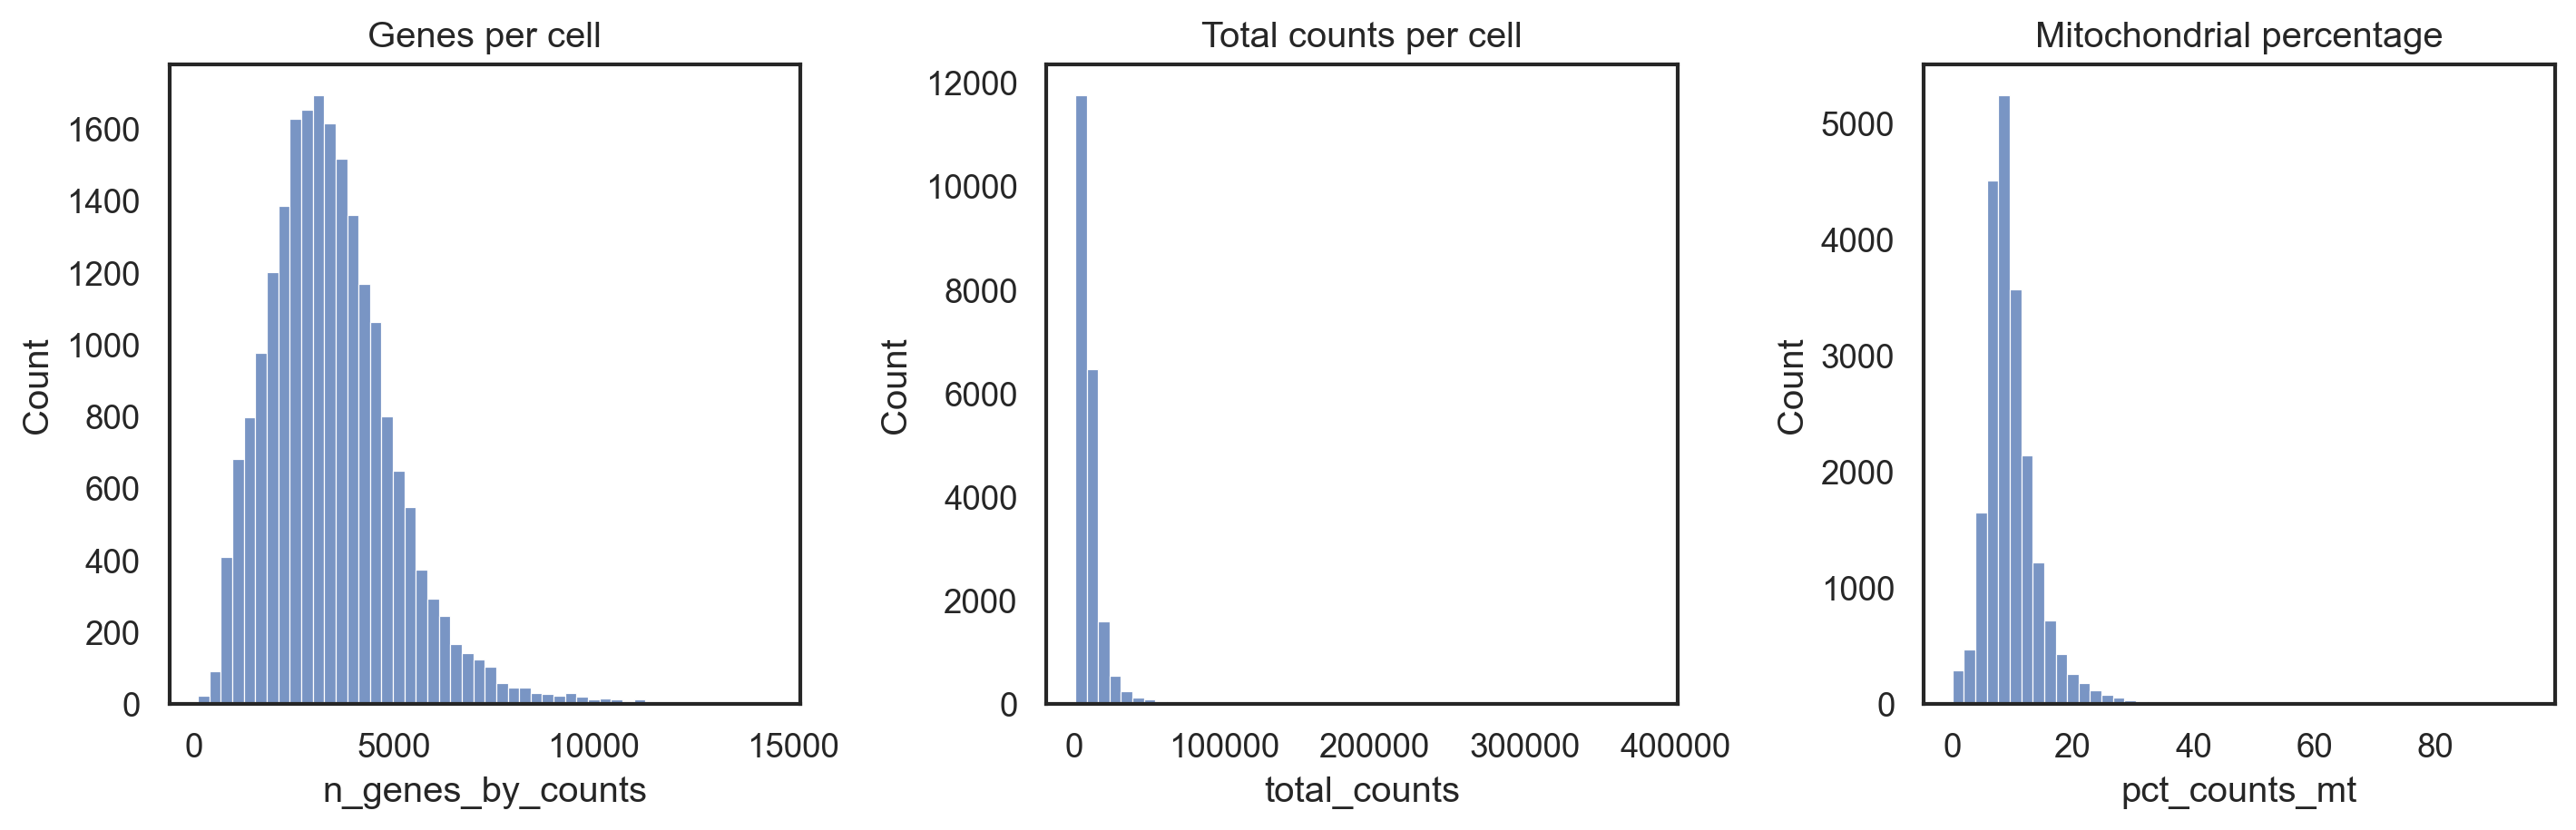

In [9]:
# Plot QC histograms
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(adata.obs["n_genes_by_counts"], bins=50, ax=axes[0])
axes[0].set_title("Genes per cell")
axes[0].set_xlabel("n_genes_by_counts")

sns.histplot(adata.obs["total_counts"], bins=50, ax=axes[1])
axes[1].set_title("Total counts per cell")
axes[1].set_xlabel("total_counts")

sns.histplot(adata.obs["pct_counts_mt"], bins=50, ax=axes[2])
axes[2].set_title("Mitochondrial percentage")
axes[2].set_xlabel("pct_counts_mt")

plt.tight_layout()
plt.show()

In [10]:
# Inspect author-provided QC label
adata.obs["high_quality"].value_counts()

high_quality
True     20672
False      372
Name: count, dtype: int64

In [11]:
# Inspect mitochondrial summary
adata.obs["pct_counts_mt"].describe()

count    21044.000000
mean         9.811918
std          5.083063
min          0.039032
25%          7.050895
50%          8.880663
75%         11.488234
max         95.053009
Name: pct_counts_mt, dtype: float64

# 05 - Filter Low-Quality Cells

Cells are filtered using:
- minimum genes per cell: 500
- maximum genes per cell: 8000
- mitochondrial percentage < 20

In [12]:
# Filter cells
adata_qc = adata[
    (adata.obs["n_genes_by_counts"] > 500) &
    (adata.obs["n_genes_by_counts"] < 8000) &
    (adata.obs["pct_counts_mt"] < 20)
].copy()

# Report filtering
print("Cells before QC:", adata.n_obs)
print("Cells after QC:", adata_qc.n_obs)

Cells before QC: 21044
Cells after QC: 20093


# 06 - Normalize and Log-Transform

Counts are normalized per cell and log-transformed.

In [13]:
# Store raw data
adata_qc.raw = adata_qc

# Normalize counts
sc.pp.normalize_total(adata_qc, target_sum=1e4)

# Log-transform counts
sc.pp.log1p(adata_qc)

normalizing counts per cell
    finished (0:00:01)


# 07 - Select Highly Variable Genes

Highly variable genes are selected for dimensionality reduction and clustering.

In [14]:
# Find HVGs
sc.pp.highly_variable_genes(
    adata_qc,
    flavor="seurat",
    n_top_genes=2000
)

# Report HVGs
print("Number of highly variable genes:", adata_qc.var["highly_variable"].sum())

extracting highly variable genes
    finished (0:00:01)
Number of highly variable genes: 2000


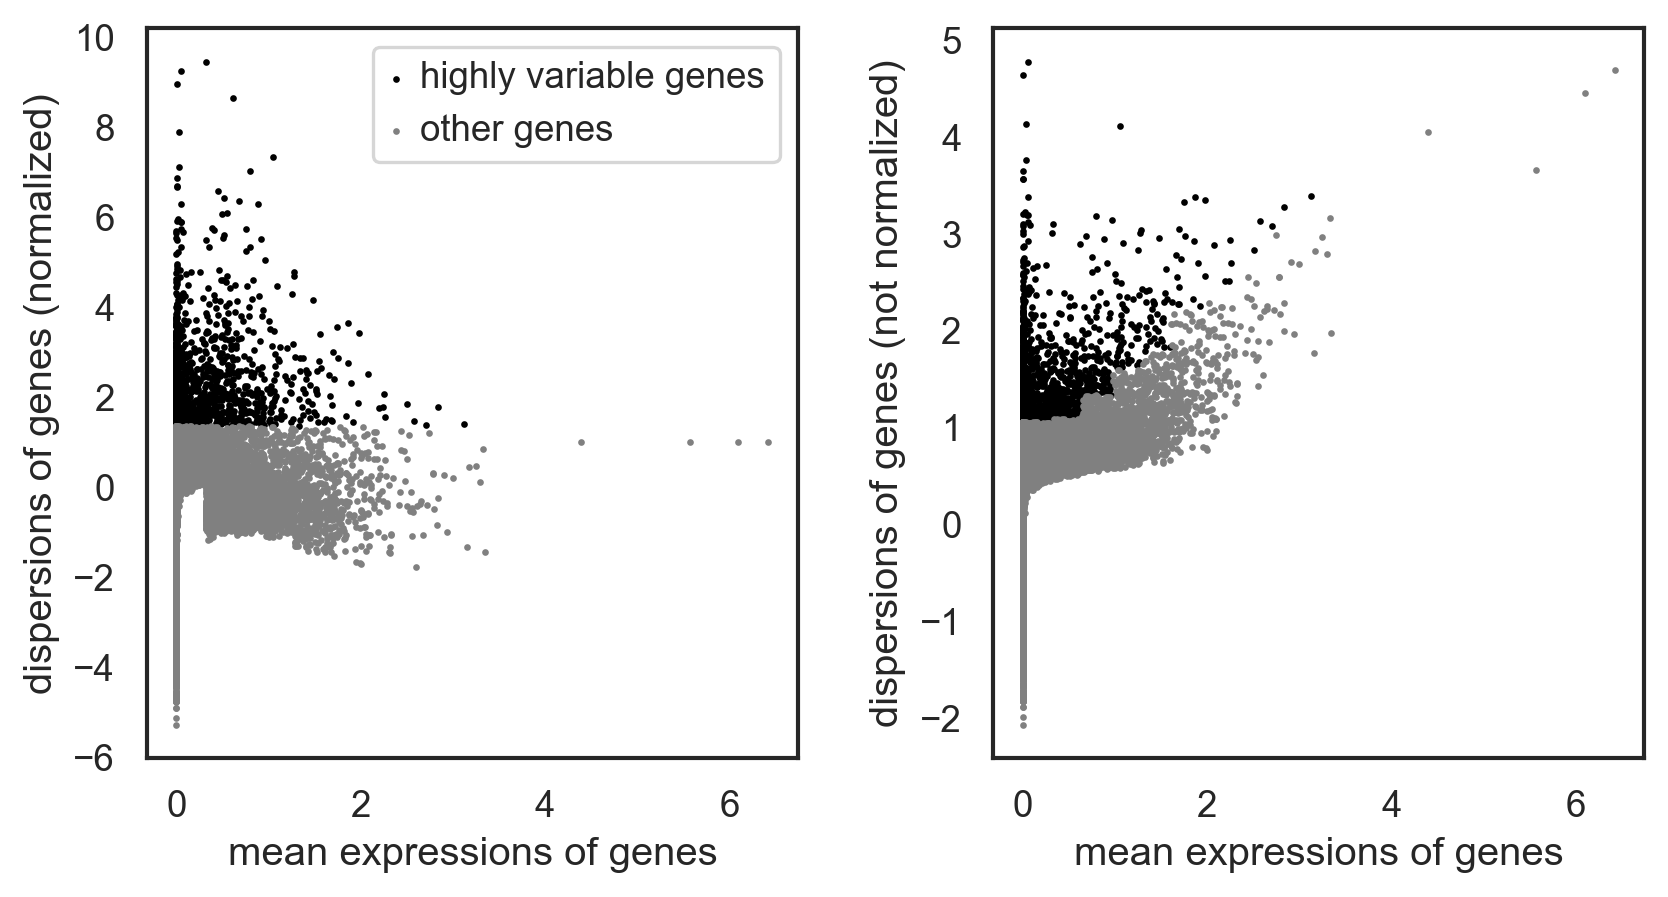

In [15]:
# Plot HVGs
sc.pl.highly_variable_genes(adata_qc)

In [16]:
# Keep HVGs only
adata_qc = adata_qc[:, adata_qc.var["highly_variable"]].copy()

# Report retained genes
print("Genes retained:", adata_qc.n_vars)

Genes retained: 2000


# 08 - Scale Data

Gene expression values are scaled before PCA.

In [17]:
# Scale expression matrix
sc.pp.scale(adata_qc, max_value=10)

/opt/anaconda3/envs/scRNA/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


# Save Processed Data

In [18]:
adata_qc.write("../results/adata_qc_preprocessed.h5ad")

## Summary

- Loaded and inspected the GEO scRNA-seq dataset (GSE272840) in AnnData format
- Explored experimental conditions and cell distribution across timepoints, infection status, and treatment
- Assessed data quality using standard QC metrics:
  - number of detected genes per cell
  - total counts per cell
  - mitochondrial gene percentage
- Filtered low-quality cells using predefined thresholds:
  - 500 < genes per cell < 8000
  - mitochondrial percentage < 20%
- Normalized counts per cell and applied log-transformation
- Identified 2,000 highly variable genes for downstream analysis
- Scaled gene expression values for dimensionality reduction

The preprocessed dataset was saved for downstream clustering and annotation:
`../results/adata_qc_preprocessed.h5ad`